In [23]:
%autosave 60

Autosaving every 60 seconds


# Домашнее задание EDA | МТС Тета
-----
- Нужно провести EDA любого датасета на ваше усмотрение в специально подготовленном ipynb
- В этом ноутбуке будут блоки под разные типы графиков
- Нужно выбрать такой датасет, который позволит построить каждый из этих графиков корректно
- В ноутбуке так же будет дополнительное поле для графика на ваш выбор. В нем должен быть график, который не был построен ранее в ноутбуке (другой тип графика)
- Ноутбук должен отбегать в режиме run all, а так же сохранять все изображения шаблонным образом, как заложено в ноутбуке
- Для каждого графика должны быть написаны выводы
- __Вместе с ноутбуком нужно сдать сохраненные изображения (проверьте корректность их сохранения перед отправкой ДЗ)__
- изображения должны быть в формате png или jpeg. Не сохраняйте изображения в html (так делает plotly)
____
**Критерии оценки**
- Вы построили все основные графики без критических ошибок – 8 баллов
- Вы выполнили пункт 1, а так же построили дополнительный график - 10 баллов
- Доп. баллы выставляются за победу в tinder игре – подробности будут позже. Но чтобы в ней победить, ваш график должен оказаться самым красивым. 
- Доп. Баллы получат топ 10 человек итогового рейтинга. 
---
- Максимум 10 баллов (и +5 дополнительных)
- 1-4 балла: незачет
- 5-6 баллов: 3, незачет
- 7-8 баллов: 4, зачет
- 9-10 баллов: 5, зачет

## подготовка

In [24]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

In [25]:
# подставьте ваше имя и фамилию в эту переменную как в примере, (например Максим_Шаланкин)
image_name_prefix = 'Екатерина_Галаева'

# можно поменять, а можно оставить - сюда будут сохраняться изображения
path_to_save_images = 'images'

In [26]:
os.makedirs(path_to_save_images, exist_ok=True)

In [27]:
import kagglehub

#!kaggle datasets download -d abdulmalik1518/mobiles-dataset-2025
#!unzip mobiles-dataset-2025.zip


In [28]:
df = pd.read_csv('Mobiles.csv', encoding='unicode_escape')
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


Уберем размерности в данных

In [29]:

df['Mobile Weight'] = df['Mobile Weight'].str.extract(r'(\d+)').astype(float)
df['RAM'] = df['RAM'].str.extract(r'(\d+)')[0].astype(int)
df['Front Camera'] = df['Front Camera'].str.extract(r'(\d+)').astype(float)
df['Back Camera'] = df['Back Camera'].str.extract(r'(\d+)').astype(float)
df['Processor'] = df['Processor'].str.extract(r'(\d+)').astype(float)
df['Battery Capacity'] = df['Battery Capacity'].str.extract(r'(\d+)').astype(float)
df['Screen Size'] = df['Screen Size'].str.extract(r'(\d+)').astype(float)
df['Launched Price (USA)'] = df['Launched Price (USA)'].str.extract(r'(\d+)').astype(float)
df['Launched Price (India)'] = df['Launched Price (India)'].str.extract(r'(\d[\d,]*)')[0].str.replace(',', '', regex=False).astype(float)
df['Launched Price (Pakistan)'] = df['Launched Price (Pakistan)'].str.extract(r'(\d[\d,]*)')[0].str.replace(',', '', regex=False).astype(float)
df['Launched Price (Dubai)'] = df['Launched Price (Dubai)'].str.extract(r'(\d[\d,]*)')[0].str.replace(',', '', regex=False).astype(float)
df['Launched Price (China)'] = df['Launched Price (China)'].str.extract(r'(\d[\d,]*)')[0].str.replace(',', '', regex=False).astype(float)

In [30]:
df

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174.0,6,12.0,48.0,17.0,3.0,6.0,224999.0,79999.0,5799.0,799.0,2799.0,2024
1,Apple,iPhone 16 256GB,174.0,6,12.0,48.0,17.0,3.0,6.0,234999.0,84999.0,6099.0,849.0,2999.0,2024
2,Apple,iPhone 16 512GB,174.0,6,12.0,48.0,17.0,3.0,6.0,244999.0,89999.0,6499.0,899.0,3199.0,2024
3,Apple,iPhone 16 Plus 128GB,203.0,6,12.0,48.0,17.0,4.0,6.0,249999.0,89999.0,6199.0,899.0,3199.0,2024
4,Apple,iPhone 16 Plus 256GB,203.0,6,12.0,48.0,17.0,4.0,6.0,259999.0,94999.0,6499.0,949.0,3399.0,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,Poco,Pad 5G 128GB,571.0,8,8.0,8.0,7.0,10.0,12.0,66220.0,23999.0,2099.0,280.0,1029.0,2024
926,Poco,Pad 5G 256GB,571.0,8,8.0,8.0,7.0,10.0,12.0,71220.0,25999.0,2299.0,300.0,1099.0,2024
927,Samsung,Galaxy Z Fold6 256GB,239.0,12,10.0,50.0,8.0,4400.0,7.0,604999.0,164999.0,13999.0,1.0,7199.0,2024
928,Samsung,Galaxy Z Fold6 512GB,239.0,12,10.0,50.0,8.0,4400.0,7.0,544999.0,176999.0,15999.0,1719.0,7699.0,2024


In [31]:
df['Company Name'] = df['Company Name'].replace({'POCO': 'Poco'})


In [32]:
df.columns

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')

In [33]:
sns.set(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name               930 non-null    object 
 1   Model Name                 930 non-null    object 
 2   Mobile Weight              930 non-null    float64
 3   RAM                        930 non-null    int64  
 4   Front Camera               930 non-null    float64
 5   Back Camera                930 non-null    float64
 6   Processor                  927 non-null    float64
 7   Battery Capacity           930 non-null    float64
 8   Screen Size                930 non-null    float64
 9   Launched Price (Pakistan)  929 non-null    float64
 10  Launched Price (India)     930 non-null    float64
 11  Launched Price (China)     930 non-null    float64
 12  Launched Price (USA)       930 non-null    float64
 13  Launched Price (Dubai)     930 non-null    float64

Пропусков нет

Посмотрим характеристики у колонки цены смартфонов в долларах

In [35]:
df['Launched Price (USA)'].describe()

count     930.000000
mean      385.023656
std       288.132358
min         1.000000
25%       189.000000
50%       320.000000
75%       549.000000
max      1719.000000
Name: Launched Price (USA), dtype: float64

In [36]:
!pip install mplcyberpunk
import mplcyberpunk
plt.style.use("cyberpunk")

В качестве таргета можно рассматривать цену смартфонов, но так как тут цены представлены в разных валютах, то остановимся на цене в долларах. 

## (1) line plot

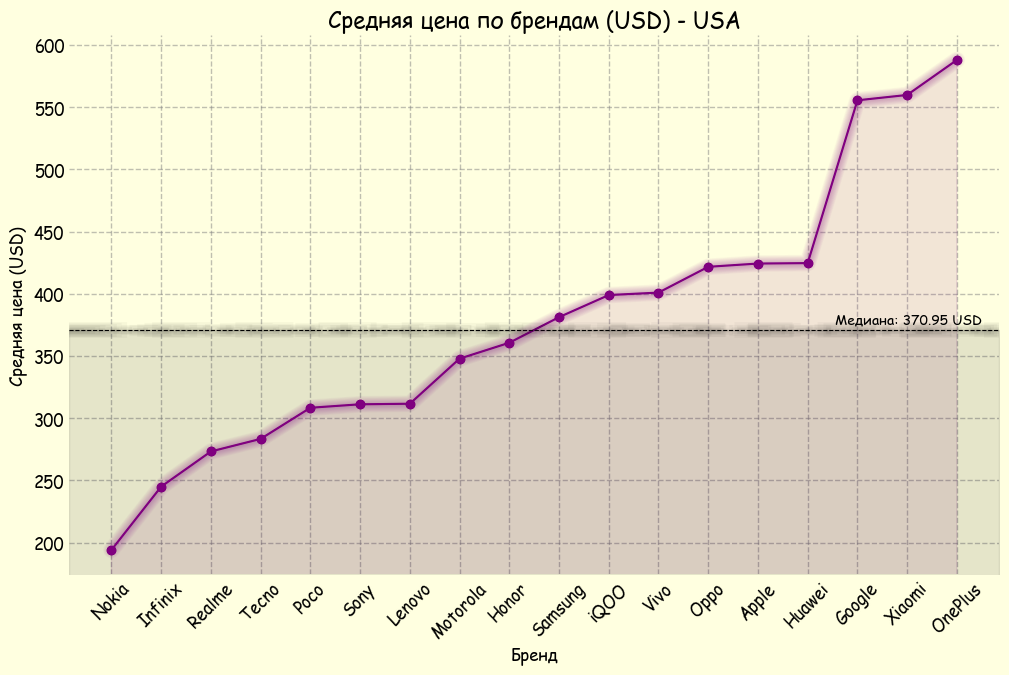

In [37]:
from matplotlib import font_manager
brand_price = df.groupby("Company Name")["Launched Price (USA)"].mean().sort_values()
font_path = '/System/Library/Fonts/Supplemental/Comic Sans MS.ttf'
prop = font_manager.FontProperties(fname=font_path, size=16)
prop_2 = font_manager.FontProperties(fname=font_path, size=12)

plt.style.use("cyberpunk")
median_price = brand_price.median()

fig = plt.figure(figsize=(12, 7), facecolor='lightyellow')
fig.patch.set_facecolor('lightyellow')  
   
ax = plt.gca()
ax.set_facecolor('lightyellow')  
plt.grid(True, linestyle="--", color="gray", alpha=0.5)
ax.set_facecolor('lightyellow') 
plt.plot(
    brand_price.index,
    brand_price.values,
    marker='o',
    linestyle='-',
    color='purple', 
    label="USA"
)

plt.axhline(y=median_price, color='black', linestyle='--', linewidth=0.8)


plt.text(
    x=len(brand_price) - 0.5, 
    y=median_price + 5,        
    s=f"Медиана: {median_price:.2f} USD",
    color='black',
    ha='right',  
    fontsize=10,
    fontproperties=prop_2
)

plt.title("Средняя цена по брендам (USD) - USA", color='black', fontproperties=prop)
plt.xlabel("Бренд", color='black', fontproperties=prop_2)
plt.ylabel("Средняя цена (USD)", color='black', fontproperties=prop_2)
plt.xticks(rotation=45, color='black', fontproperties=prop_2)
plt.yticks(color='black', fontproperties=prop_2)

mplcyberpunk.add_glow_effects()

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_1.png'),
    facecolor=fig.get_facecolor(),  
    bbox_inches='tight',            
    dpi=300                       
)
plt.show()



#### выводы (1): 
В целом, график позволяет быстро оценить ценовой диапазон основных брендов и сделать вывод, что сегментация рынка в США весьма разнообразна: от бюджетных моделей до премиум-устройств. Из графика видно, что самую высокую среднюю цену (около 560 USD) в США демонстрирует бренд OnePlus. А также можно определить, что количество брендов выше и ниже медианного значения практически равное.

## (2) (bar plot или stacked bar plot)

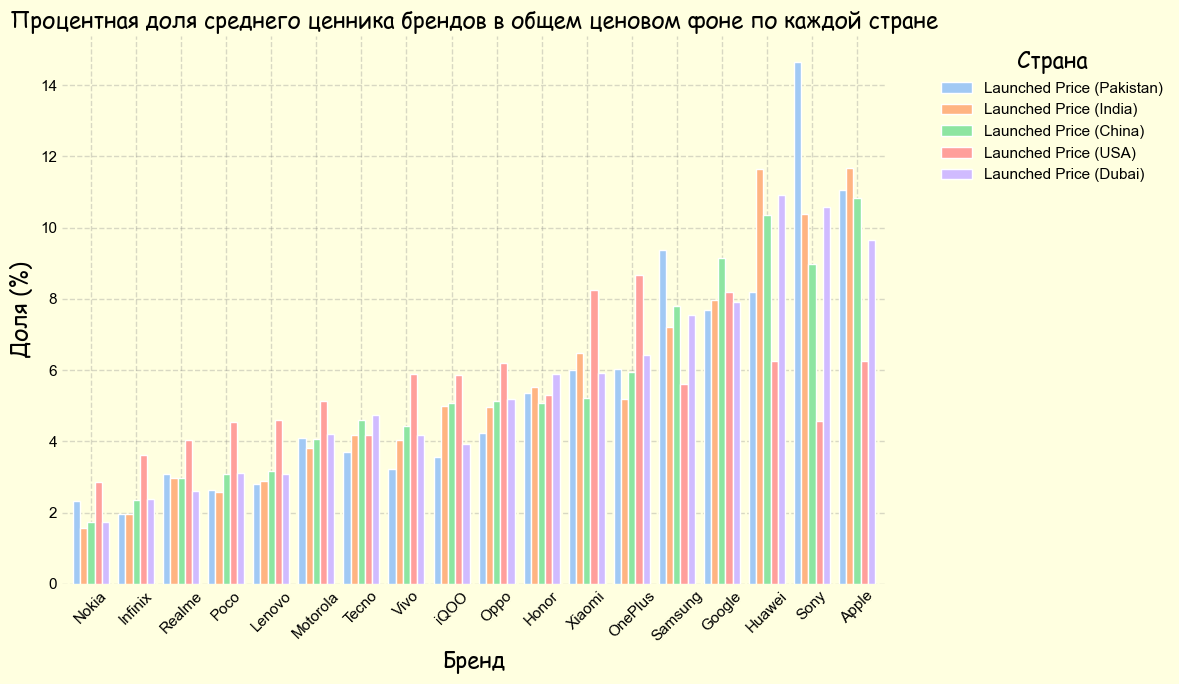

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import mplcyberpunk
import matplotlib.font_manager as font_manager


plt.rcParams['font.size'] = 12
prop = font_manager.FontProperties(fname=font_path, size=16)
import pandas as pd


price_columns = [
    "Launched Price (Pakistan)",
    "Launched Price (India)",
    "Launched Price (China)",
    "Launched Price (USA)",
    "Launched Price (Dubai)"
]


df_prices = df.groupby("Company Name")[price_columns].mean()


df_prices_pct = df_prices.div(df_prices.sum(axis=0), axis=1) * 100


df_prices_pct_sorted = df_prices_pct.loc[df_prices_pct.sum(axis=1).sort_values().index]



fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('lightyellow')  
ax.set_facecolor('lightyellow')  

custom_colors = sns.color_palette("pastel", 5)

df_prices_pct_sorted.plot(
    kind="bar",
    stacked=False,
    color=custom_colors,
    width=0.8,
    ax=ax
)

plt.title("Процентная доля среднего ценника брендов в общем ценовом фоне по каждой стране", 
          fontproperties=prop, color='black', fontsize=16)
plt.xlabel("Бренд", fontproperties=prop, color='black')
plt.ylabel("Доля (%)", fontproperties=prop, color='black')
plt.xticks(rotation=45, color='black')
plt.yticks(color='black')

leg = plt.legend(title="Страна", bbox_to_anchor=(1.05, 1), loc='upper left')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.8)
for text in leg.get_texts():
    text.set_color("black")
leg.get_title().set_color("black")
leg.get_title().set_fontproperties(prop)

ax.grid(True, linestyle='--', color='gray', alpha=0.3)

mplcyberpunk.add_glow_effects()

plt.tight_layout()

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_2.png'),
    facecolor=fig.get_facecolor(),  
    bbox_inches='tight',            
    dpi=300                       
)

plt.show()


#### выводы (2): написать выводы
График хорошо показывает, какую часть (в процентах) от общего ценового фонда страны занимает средняя цена каждого бренда. 

В левой части графика (Nokia, Infinix, Realme и другие) доли по всем странам относительно невысоки, что говорит о более низком уровне средних цен этих брендов.
В правой части (например, Huawei, Sony, Apple) суммарная доля заметно выше, следовательно, их средние цены на разных рынках оказываются существенно выше, чем у других брендов.

Также можно сделать сравнение внутри каждой страны. Поскольку каждая колонка соответствует определенной стране, можно быстро увидеть, какой бренд имеет наибольшую долю в каждой стране (а значит, и более высокую среднюю цену по сравнению с конкурентами в этой стране). Различия в высоте столбцов одной цветовой группы показывают, что одни бренды более дорогие в определенных странах, а в других – занимают меньшую долю. 
Также можно провести анализ внутри каждого бренда по разным странам. Стоит обратить внимание, что у таких брендов, как Huawei, Sony, Apple средняя цена в разных странах существенно отличается, что нельзя сказать про бренды, которые расположены в левой части графика.

##  (3) (hist plot или pair plot или kde plot)

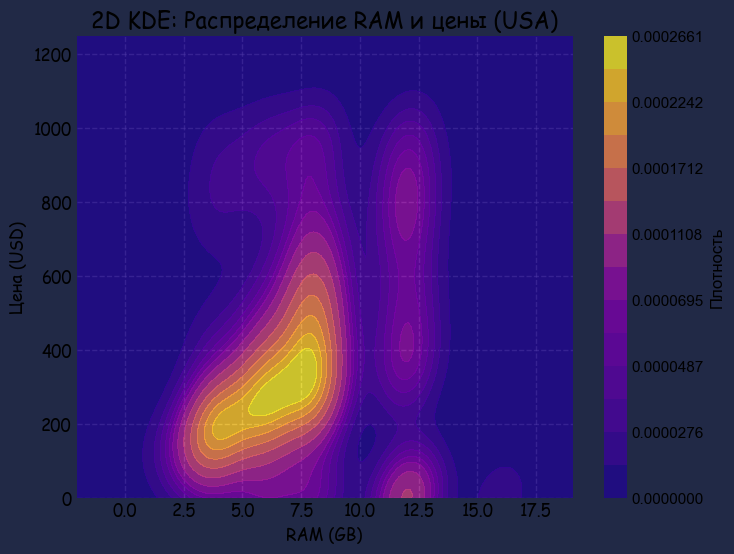

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
df_plot = df[['RAM', 'Launched Price (USA)']].copy()

sns.kdeplot(
    data=df_plot,
    x='RAM',
    y='Launched Price (USA)',
    cmap='plasma',
    fill=True,
    color='black',
    thresh=0,
    levels=15,
    alpha=0.8,
    cbar=True,  
    cbar_kws={'label': 'Плотность'}  
)
cbar = plt.gcf().axes[-1]
cbar.set_ylabel('Плотность', color='black')
cbar.yaxis.label.set_color('black')
plt.setp(cbar.get_yticklabels(), color='black')
plt.title("2D KDE: Распределение RAM и цены (USA)", fontproperties=prop, color='black')
plt.xlabel("RAM (GB)", fontproperties=prop_2, color='black')
plt.ylabel("Цена (USD)", fontproperties=prop_2, color='black')
plt.xticks(fontproperties=prop_2, color='black')
plt.yticks(fontproperties=prop_2, color='black')


plt.grid(True, linestyle='--', color='white', alpha=0.5)

plt.ylim(0, 1250)
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_3.png'),
    facecolor=fig.get_facecolor(),  
    bbox_inches='tight',            
    dpi=300                       
)
plt.show()


#### выводы (3): написать выводы
Основная концентрация устройств наблюдается в диапазоне от 4 до 8 ГБ оперативной памяти и ценой до ~400 USD. Это указывает на то, что большая часть моделей с умеренным объемом RAM находится в более доступном ценовом сегменте.
Есть второй ярко выраженный кластер устройств с 10–12 ГБ RAM и ценой в районе 400–1000 USD. Эти устройства, вероятнее всего, относятся к категории средне-высокого уровня. А также есть еще одна категория с тем же значением RAM, но ценой в диапазоне до 150 USD.

В целом, увеличение объема RAM в большинстве случаев сопровождается ростом цены, хотя график показывает и некоторые исключения, где цена может быть несколько ниже или выше ожидаемого уровня для данного объема оперативной памяти.

##  (4) heatmap plot

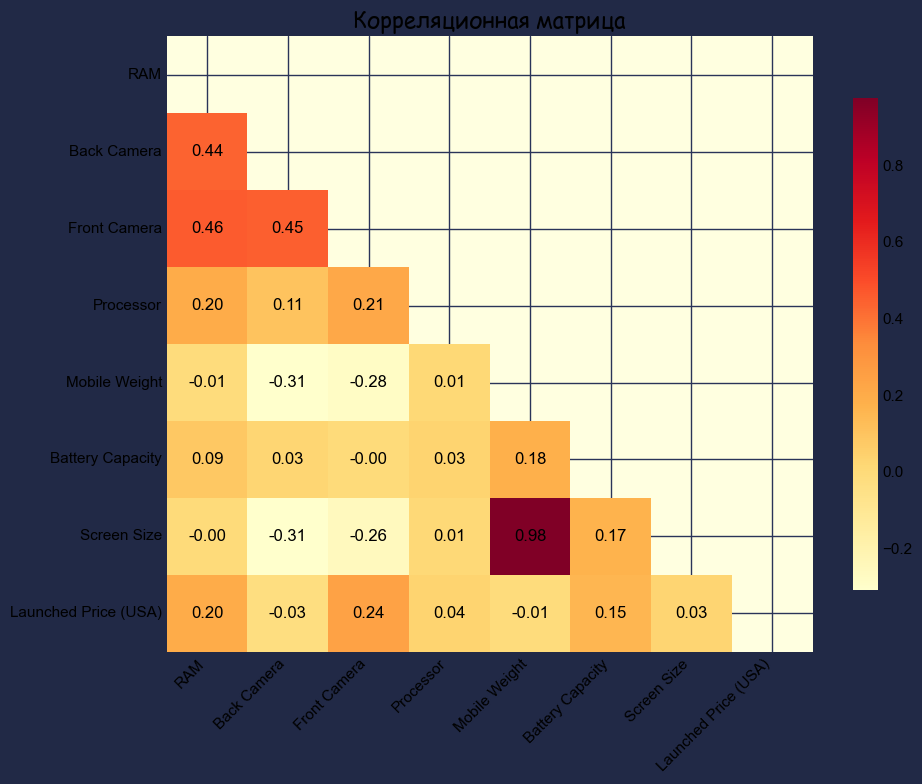

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def custom_formatter(x, pos):
    s = format(x, ".2f")
    if s == "-0.00":
        s = "0.00"
    return s

df_corr = df[[
    'RAM',
    'Back Camera',
    'Front Camera',
    'Processor',
    'Mobile Weight',
    'Battery Capacity',
    'Screen Size',
    'Launched Price (USA)'
]].copy()

df_corr.dropna(inplace=True)

corr = df_corr.corr()

annot = (
    corr
    .stack()
    .map(lambda x: "0.00" if x == 0 else f"{x:.2f}")
    .unstack()
)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
fig.patch.set_facecolor('lightyellow')  
ax.set_facecolor('lightyellow')  

heatmap = sns.heatmap(
    corr,
    mask=mask,
    annot=True,          
    fmt=".2f",           
    cmap='YlOrRd',  
    annot_kws={'color': 'black'},      
    square=False,        
    linewidths=0,      
    linecolor=None,  
    cbar_kws={"shrink": .8}  
)
heatmap.set_facecolor('lightyellow')

cbar = heatmap.collections[0].colorbar

cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.get_yticklabels(), color='black')
plt.title("Корреляционная матрица", fontproperties=prop, color='black')
plt.xticks(rotation=45, ha='right', color='black')
plt.yticks(color='black')
plt.tight_layout()

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_4.png'),
    facecolor=fig.get_facecolor(),  
    bbox_inches='tight',            
    dpi=300                       
)

plt.show()



#### выводы (4): написать выводы
Screen Size и Mobile Weight: Самая сильная положительная корреляция (0.98). Это говорит о том, что устройства с большим весом почти всегда имеют большой экран, что логично.

RAM и Back Camera: Умеренная положительная корреляция (0.44). Можно предположить, что более продвинутые модели с увеличенным объемом оперативной памяти часто оснащаются и более качественной/высокопиксельной камерой.

RAM и Price (USA): Небольшая корреляция (0.20). Из этого можно сделать вывод, что в данном датасете объем оперативной памяти не является ключевым фактором, определяющим цену на рынке США, или же в выборке присутствуют и дорогие устройства с обычным объемом RAM, и относительно дешевые, но с большей RAM.

Отрицательная корреляция между Screen Size и Back Camera и другие пары может указывать на то, что устройства с большими значениями одного параметра не всегда увеличивают другой.

В целом, сильных линейных связей с ценой в долларах здесь не обнаружено, что намекает: цена может больше зависеть от бренда, процессора и других факторов, не отраженных явно в выбранных столбцах.



##  (5) plot  на ваш выбор

In [41]:
df.columns

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_24017/1598181125.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violinplot = sns.violinplot(
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_24017/1598181125.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  violinplot = sns.violinplot(
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_24017/1598181125.py:19: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  violinplot = sns.violinplot(


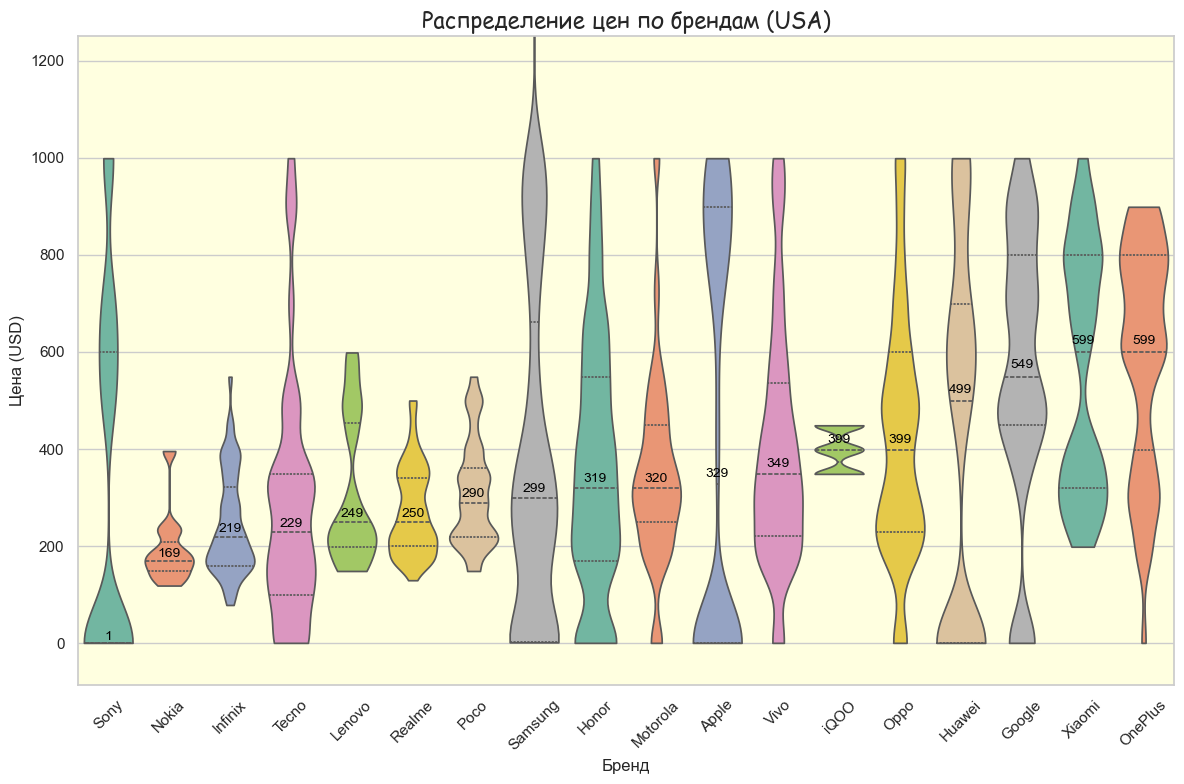

In [42]:


brand_counts = df['Company Name'].value_counts()
df_filtered = df[df['Company Name'].isin(brand_counts[brand_counts >= 3].index)].copy()

order = (
    df_filtered
    .groupby('Company Name')['Launched Price (USA)']
    .median()
    .sort_values()
    .index
)

sns.set_theme(style="whitegrid")  

plt.figure(figsize=(12, 8))

fig.patch.set_facecolor('lightyellow')  
ax.set_facecolor('lightyellow')  

violinplot = sns.violinplot(
    x='Company Name',
    y='Launched Price (USA)',
    data=df_filtered,
    order=order,
    palette='Set2',
    scale='width',       
    inner='quartile',    
    cut=0,              
    bw=0.2               
)
violinplot.set_facecolor('lightyellow')

plt.title('Распределение цен по брендам (USA)', fontproperties=prop)
plt.xlabel('Бренд', fontsize=12)
plt.ylabel('Цена (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(top=1250)  

plt.tight_layout()

median_vals = (
    df_filtered
    .groupby('Company Name')['Launched Price (USA)']
    .median()
    .reindex(order)
)

for i, brand in enumerate(order):
    m = median_vals[brand]
    plt.text(
        x=i, 
        y=m + (m * 0.02 if m > 0 else 10), 
        s=f'{m:.0f}',
        ha='center',
        va='bottom',
        color='black',
        fontsize=10
    )




plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_5.png'),
    facecolor=fig.get_facecolor(),  
    bbox_inches='tight',            
    dpi=300                       
)

plt.show()


данный график хорошо заменяет такой 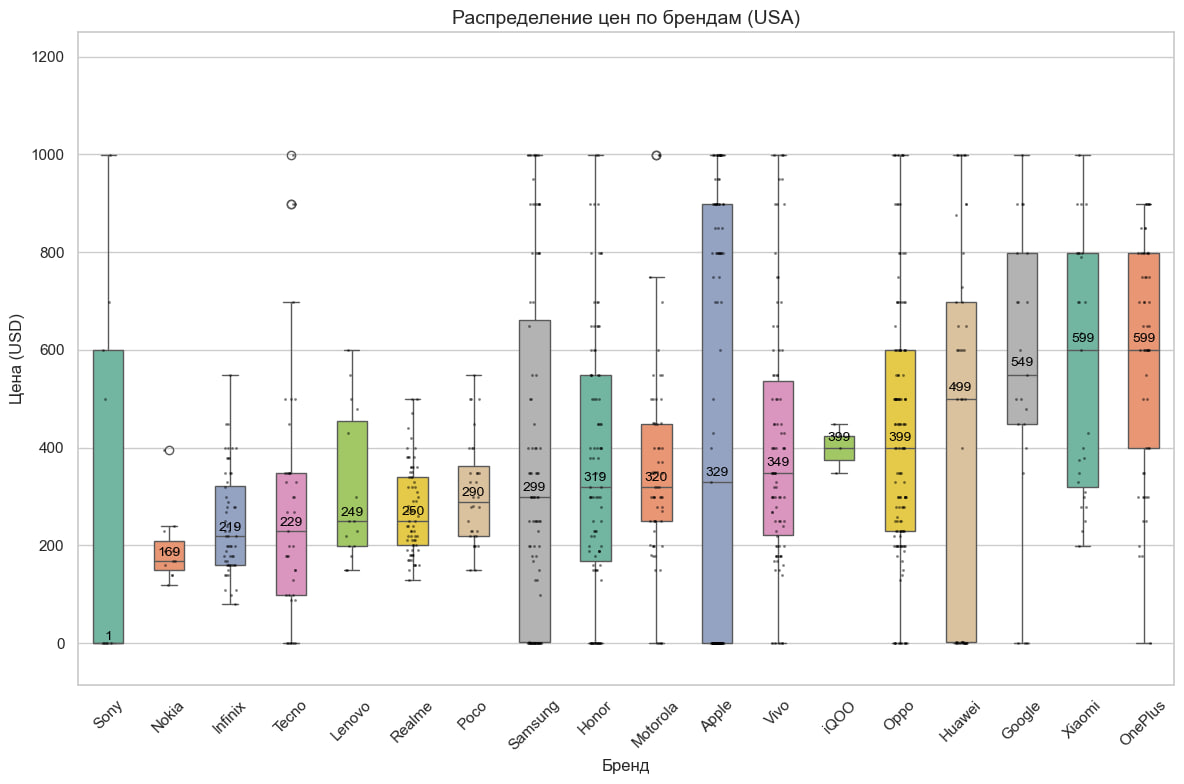

#### выводы (5): 

1. Диапазон цен заметно различается между брендами: у некоторых (например, Sony, Nokia, Infinix) медианные цены находятся на уровне до 200–250 USD, а у других (OnePlus, Google, Xiaomi) медиана поднимается выше 500 USD.  
2. Бренд Nokia имеет цены в районе 170–200 USD. У этого бренда сравнительно небольшой разброс, что говорит о том, что большинство их моделей в выборке сконцентрировано в нижнем ценовом сегменте.  
3. Самые дорогие по медиане бренды – OnePlus, Google, Xiaomi (свыше 549 USD). 
4. У ряда брендов (например, Apple, Huawei) наблюдается широкий разброс: от относительно бюджетных моделей (возможно, прошлых поколений или базовых линеек) до дорогих.  
5. Некоторые бренды (например, iQOO) имеют довольно компактный ящик, что свидетельствует о более однородном ценовом диапазоне у представленных в датасете моделей.  
6. Сортировка по медиане наглядно показывает, какие бренды в среднем дешевле или дороже: слева располагаются наиболее доступные, а справа – самые премиальные.  

В целом, график указывает на существенное ценовое расслоение рынка: одни бренды (чаще ориентированные на бюджетные модели) имеют узкий и низкий ценовой диапазон, а другие  – гораздо более широкий разброс и более высокую медиану цен.

# Итоговый вывод по всему датасету (по всему EDA)
Итоговый вывод по результатам EDA:

Рынок мобильных устройств представлен широким спектром брендов, заметно различающихся по ценовым сегментам и позиционированию.
На цену влияет совокупность факторов: бренд, технические характеристики (оперативная память, камера, процессор) и т.д.
В целом, увеличение RAM в среднем поднимают цену, но не являются решающими.
Экран и вес сильно коррелируют между собой, но эта пара не дает высокой корреляции непосредственно с ценой, что говорит о разнообразии подходов производителей к комплектации.
Таким образом, EDA показывает сложное, многокомпонентное ценообразование в зависимости от бренда, характеристик и рынка каждой страны, а также подчеркивает сильную разницу ассортимента внутри отдельных брендов.

In [43]:
print('well done!')

well done!
